# Dataset 0 — apprentissage normal par distances KDE/PCA

Ce notebook apprend le comportement normal du dataset0 : cleaning, scaling, PCA, KDE, puis profil normal par identifiant avec des distances robustes.

La décision par identifiant n'utilise plus le pourcentage de fenêtres anormales.


In [34]:
import os
import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import tsfel
import time
import numpy as np

# Chemins robustes : le notebook peut être ouvert depuis ST4/, dataset0/ ou dataset1/
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name in ["dataset0", "dataset1"] else CURRENT_DIR
DATASET0_DIR = PROJECT_DIR / "dataset0"
DATASET1_DIR = PROJECT_DIR / "dataset1"

print("PROJECT_DIR  =", PROJECT_DIR)
print("DATASET0_DIR =", DATASET0_DIR)
print("DATASET1_DIR =", DATASET1_DIR)


PROJECT_DIR  = c:\Users\user\Documents\ST4
DATASET0_DIR = c:\Users\user\Documents\ST4\dataset0
DATASET1_DIR = c:\Users\user\Documents\ST4\dataset1


In [35]:
nSet = 0
fileTS = str(DATASET0_DIR / "pdfTimeSeries{:d}.pkl".format(nSet))
pdfTS = pd.read_pickle(fileTS)

In [36]:
pdfTS

,u,y,i,e
0,0.000000,-0.076287,9N6FK96G8,-0.076287
1,0.000000,0.019506,9N6FK96G8,0.019506
2,0.000000,-0.073928,9N6FK96G8,-0.073928
3,0.000000,0.044727,9N6FK96G8,0.044727
4,0.000000,-0.010317,9N6FK96G8,-0.010317
...,...,...,...,...
718,-0.465181,-0.449052,UMTMULQVC,0.016130
719,-0.465181,-0.417802,UMTMULQVC,0.047379
720,-0.465181,-0.510018,UMTMULQVC,-0.044837
721,-0.465181,-0.507332,UMTMULQVC,-0.042151


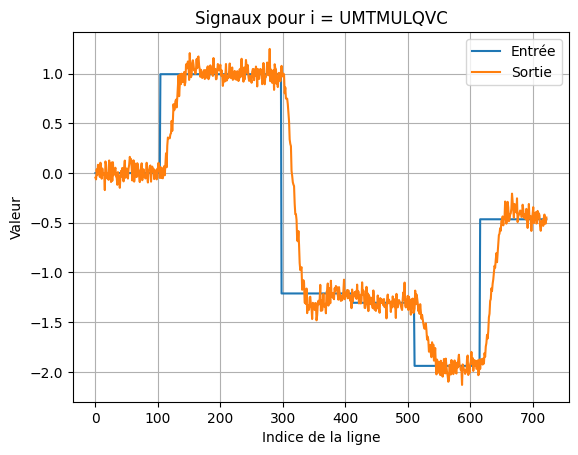

In [37]:
identifiant = "UMTMULQVC"

pdfTS_filtre = pdfTS[pdfTS["i"] == identifiant]

pdfTS_filtre["u"].plot(label="Entrée")
pdfTS_filtre["y"].plot(label="Sortie")


plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [38]:
fileEF = str(DATASET0_DIR / "pdfFeatures{:d}.pkl".format(nSet))
pdfEF = pd.read_pickle(fileEF)

In [39]:
pdfEF

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.030425,0.057124,1.0,0.016903,0.799343,2.0,8.0,-0.073928,0.044727,0.1,...,0.004341,0.003173,0.001785,0.00109,0.000761,0.00059,0.000489,0.000423,6.0,9N6FK96G8
1,0.034108,0.071956,2.0,0.018949,0.870813,2.0,8.0,-0.068527,0.031442,0.1,...,0.003611,0.003788,0.003008,0.002341,0.001897,0.001597,0.001382,0.001221,4.0,9N6FK96G8
2,0.042274,0.083902,1.0,0.023486,0.962404,2.0,8.0,-0.105961,0.016858,0.1,...,0.001518,0.000854,0.000852,0.000831,0.000794,0.000749,0.000702,0.000656,4.0,9N6FK96G8
3,0.033578,0.080128,2.0,0.018654,0.551002,2.0,8.0,-0.104259,0.021024,0.1,...,0.007749,0.006425,0.00425,0.003015,0.002334,0.001921,0.001645,0.001445,3.0,9N6FK96G8
4,0.023003,0.049324,1.0,0.012779,1.067663,2.0,8.0,-0.015203,0.035602,0.1,...,0.0012,0.001165,0.000987,0.000811,0.000682,0.00059,0.00052,0.000465,4.0,9N6FK96G8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49311,0.058049,0.090205,1.0,0.032249,0.799835,2.0,8.0,-0.087101,0.032083,0.1,...,0.031444,0.015267,0.019952,0.027048,0.031054,0.032461,0.032345,0.031438,0.0,UMTMULQVC
49312,0.035514,0.066874,1.0,0.01973,0.918799,2.0,8.0,-0.038623,0.032083,0.1,...,0.017774,0.017436,0.023716,0.028415,0.030289,0.030336,0.02944,0.028123,0.0,UMTMULQVC
49313,0.035254,0.063878,1.0,0.019586,0.700099,2.0,8.0,-0.038623,0.070625,0.1,...,0.012935,0.018426,0.027143,0.031986,0.033404,0.032951,0.031636,0.029988,0.0,UMTMULQVC
49314,0.041431,0.080162,1.0,0.023017,1.048823,2.0,8.0,-0.073158,0.060267,0.1,...,0.032227,0.018178,0.02272,0.029591,0.033423,0.034674,0.034409,0.033364,0.0,UMTMULQVC


***DATA PREP***

Step 1,2,3 : Cleaning, scaling and spliting data

In [40]:
import numpy as np
import pandas as pd

df = pdfEF.copy()

X = df.drop(columns=["i"], errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)

# Supprimer les colonnes complètement vides
X = X.dropna(axis=1, how="all")

# Médianes apprises sur dataset0
feature_medians = X.median()

# Remplir les NaN avec les médianes dataset0
X = X.fillna(feature_medians)

# Supprimer les colonnes constantes
X = X.loc[:, X.nunique(dropna=True) > 1]

# Colonnes finales utilisées par le modèle
feature_columns = X.columns.tolist()

# On garde seulement les médianes des colonnes conservées
feature_medians = feature_medians.reindex(feature_columns)

print("Shape après cleaning :", X.shape)
print("Nombre de features conservées :", len(feature_columns))

Shape après cleaning : (49316, 246)
Nombre de features conservées : 246


Split

In [41]:
from sklearn.model_selection import train_test_split

ids = df["i"].unique()

ids_train, ids_test = train_test_split(
    ids,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

idx_train = df[df["i"].isin(ids_train)].index
idx_test = df[df["i"].isin(ids_test)].index

X_train = X.loc[idx_train]
X_test = X.loc[idx_test]

print("Nombre identifiants train :", len(ids_train))
print("Nombre identifiants test  :", len(ids_test))
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

Nombre identifiants train : 160
Nombre identifiants test  : 40
X_train : (39033, 246)
X_test  : (10283, 246)


Scaling

In [42]:
from sklearn.preprocessing import RobustScaler
# Scaling appris uniquement sur le train normal
scaler = RobustScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

print("Scaling terminé")    

Scaling terminé


In [43]:
from sklearn.decomposition import PCA

# PCA apprise uniquement sur le train normal
pca = PCA(n_components=2, random_state=42).fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_pca = pca.transform(X_scaled)

print("Variance expliquée :", round(pca.explained_variance_ratio_.sum(), 4))
print("Nombre de composantes PCA gardées :", X_train_pca.shape)

Variance expliquée : 0.9638
Nombre de composantes PCA gardées : (39033, 2)


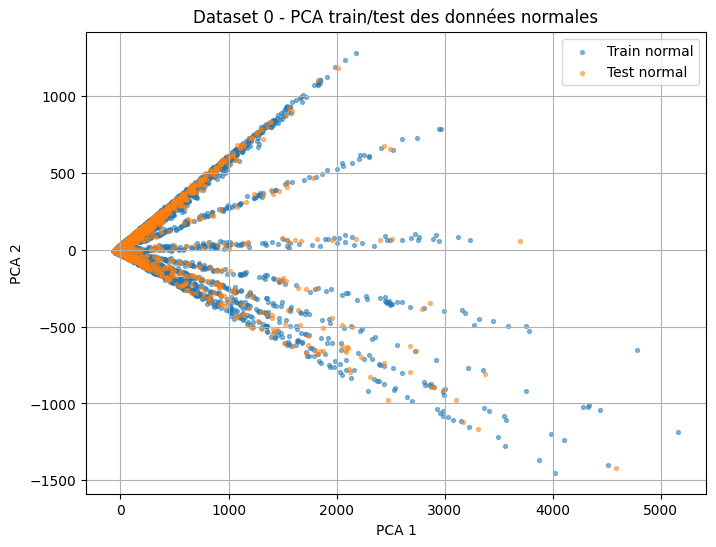

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    s=8,
    alpha=0.5,
    label="Train normal"
)

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    s=8,
    alpha=0.5,
    label="Test normal"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Dataset 0 - PCA train/test des données normales")
plt.grid()
plt.legend()
plt.show()

In [45]:
df_pca_train = df.iloc[idx_train].copy()
df_pca_train["PCA1"] = X_train_pca[:, 0]
df_pca_train["PCA2"] = X_train_pca[:, 1]
df_pca_train["split"] = "train"

df_pca_test = df.iloc[idx_test].copy()
df_pca_test["PCA1"] = X_test_pca[:, 0]
df_pca_test["PCA2"] = X_test_pca[:, 1]
df_pca_test["split"] = "test"

df_pca_all = pd.concat([df_pca_train, df_pca_test], axis=0)

df_pca_all[["i", "PCA1", "PCA2", "split"]].head()

,i,PCA1,PCA2,split
0,9N6FK96G8,-56.612621,-9.735148,train
1,9N6FK96G8,-55.802619,-9.810549,train
2,9N6FK96G8,-56.634742,-8.907939,train
3,9N6FK96G8,-55.215088,-10.262915,train
4,9N6FK96G8,-57.141735,-9.318899,train


In [60]:
from sklearn.neighbors import KernelDensity

# KDE apprise uniquement sur les PCA du train normal
bandwidth = 5

kde = KernelDensity(
    kernel="gaussian",
    bandwidth=bandwidth
)

kde.fit(X_train_pca)

# Scores KDE
train_scores = kde.score_samples(X_train_pca)
test_scores = kde.score_samples(X_test_pca)

print("Score train moyen :", train_scores.mean())
print("Score test moyen  :", test_scores.mean())

Score train moyen : -6.633979363208597
Score test moyen  : -7.347708868595831


In [61]:
alpha = 0.05

threshold = np.quantile(test_scores, alpha)

print("Seuil KDE :", threshold)

Seuil KDE : -14.04350948795771


In [62]:
test_outlier = test_scores < threshold

print("Nombre de fenêtres test normales détectées anormales :", test_outlier.sum())
train_outlier = train_scores < threshold

print("Taux outlier train :", train_outlier.mean())
print("Taux outlier test  :", test_outlier.mean())

Nombre de fenêtres test normales détectées anormales : 515
Taux outlier train : 0.04655035482796608
Taux outlier test  : 0.05008266070212973


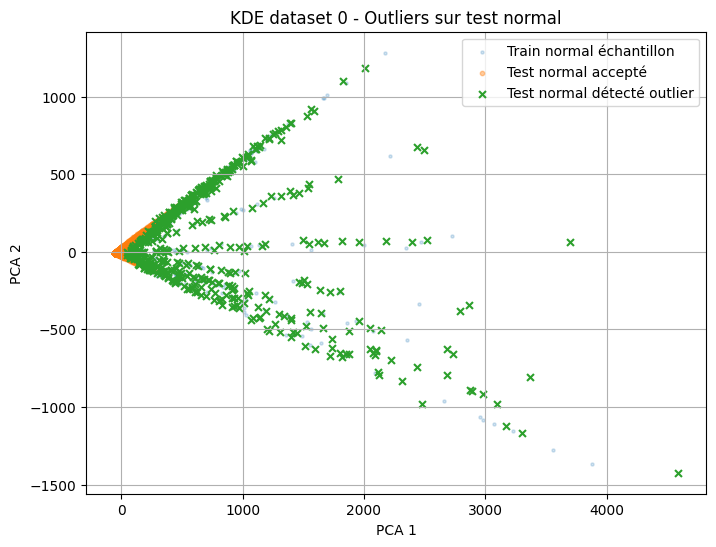

In [63]:
rng = np.random.default_rng(42)

n_plot_train = min(5000, X_train_pca.shape[0])
idx_plot_train = rng.choice(X_train_pca.shape[0], n_plot_train, replace=False)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[idx_plot_train, 0],
    X_train_pca[idx_plot_train, 1],
    s=5,
    alpha=0.2,
    label="Train normal échantillon"
)

plt.scatter(
    X_test_pca[~test_outlier, 0],
    X_test_pca[~test_outlier, 1],
    s=10,
    alpha=0.4,
    label="Test normal accepté"
)

plt.scatter(
    X_test_pca[test_outlier, 0],
    X_test_pca[test_outlier, 1],
    s=25,
    marker="x",
    label="Test normal détecté outlier"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KDE dataset 0 - Outliers sur test normal")
plt.grid()
plt.legend()
plt.show()

In [64]:
df_pca_train["kde_score"] = train_scores
df_pca_train["outlier"] = train_scores < threshold

df_pca_test["kde_score"] = test_scores
df_pca_test["outlier"] = test_scores < threshold

df_pca_all = pd.concat([df_pca_train, df_pca_test], axis=0)

# Ici, pour dataset0, on garde seulement l'information utile :
# une fenêtre est normale ou anormale selon le seuil KDE.
df_pca_all[["i", "PCA1", "PCA2", "kde_score", "outlier", "split"]].head()

,i,PCA1,PCA2,kde_score,outlier,split
0,9N6FK96G8,-56.612621,-9.735148,-5.331419,False,train
1,9N6FK96G8,-55.802619,-9.810549,-5.329532,False,train
2,9N6FK96G8,-56.634742,-8.907939,-5.331799,False,train
3,9N6FK96G8,-55.215088,-10.262915,-5.355044,False,train
4,9N6FK96G8,-57.141735,-9.318899,-5.343255,False,train


In [65]:
# ============================================================
# PROFIL NORMAL DATASET 0 PAR IDENTIFIANT
# Version distance-only : pas de pourcentage de fenêtres anormales
# ============================================================

# On garde les scores KDE fenêtre par fenêtre,
# mais la décision par identifiant ne dépend plus du % d'outliers.
df_ref = df_pca_all.copy().sort_index()

# kde.score_samples donne une log-densité.
# Plus kde_score est grand, plus la fenêtre ressemble au normal.
# On crée donc un score plus intuitif : grand = plus anormal.
df_ref["kde_anomaly_score"] = -df_ref["kde_score"]

# Centre normal dans l'espace PCA appris sur le train dataset0
pca_center_dataset0 = np.median(X_train_pca, axis=0)

# Distance de chaque fenêtre au centre PCA normal
df_ref["pca_dist_center"] = np.sqrt(
    (df_ref["PCA1"] - pca_center_dataset0[0])**2
    + (df_ref["PCA2"] - pca_center_dataset0[1])**2
)

# Fonctions quantiles utiles
def q05(x):
    return np.quantile(x, 0.05)

def q25(x):
    return np.quantile(x, 0.25)

def q75(x):
    return np.quantile(x, 0.75)

def q90(x):
    return np.quantile(x, 0.90)

def q95(x):
    return np.quantile(x, 0.95)

# Résumé par identifiant : uniquement des propriétés KDE/PCA,
# pas de pourcentage de fenêtres anormales.
id_kde_pca_stats_dataset0 = (
    df_ref
    .groupby("i")
    .agg(
        nb_windows=("kde_score", "size"),

        # Propriétés du score KDE d'anomalie
        kde_anomaly_mean=("kde_anomaly_score", "mean"),
        kde_anomaly_std=("kde_anomaly_score", "std"),
        kde_anomaly_median=("kde_anomaly_score", "median"),
        kde_anomaly_max=("kde_anomaly_score", "max"),
        kde_anomaly_q75=("kde_anomaly_score", q75),
        kde_anomaly_q90=("kde_anomaly_score", q90),
        kde_anomaly_q95=("kde_anomaly_score", q95),

        # Log-densité KDE brute
        kde_log_density_mean=("kde_score", "mean"),
        kde_log_density_min=("kde_score", "min"),
        kde_log_density_q05=("kde_score", q05),

        # Distance PCA au centre normal
        pca_dist_mean=("pca_dist_center", "mean"),
        pca_dist_std=("pca_dist_center", "std"),
        pca_dist_max=("pca_dist_center", "max"),
        pca_dist_q75=("pca_dist_center", q75),
        pca_dist_q90=("pca_dist_center", q90),
        pca_dist_q95=("pca_dist_center", q95),

        # Position et dispersion dans le plan PCA
        PCA1_mean=("PCA1", "mean"),
        PCA2_mean=("PCA2", "mean"),
        PCA1_std=("PCA1", "std"),
        PCA2_std=("PCA2", "std"),
        PCA1_min=("PCA1", "min"),
        PCA1_max=("PCA1", "max"),
        PCA2_min=("PCA2", "min"),
        PCA2_max=("PCA2", "max"),
    )
    .reset_index()
)

id_kde_pca_stats_dataset0["PCA1_range"] = (
    id_kde_pca_stats_dataset0["PCA1_max"]
    - id_kde_pca_stats_dataset0["PCA1_min"]
)

id_kde_pca_stats_dataset0["PCA2_range"] = (
    id_kde_pca_stats_dataset0["PCA2_max"]
    - id_kde_pca_stats_dataset0["PCA2_min"]
)

id_kde_pca_stats_dataset0 = (
    id_kde_pca_stats_dataset0
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

display(id_kde_pca_stats_dataset0.head())
print("Nombre d'identifiants dataset0 :", id_kde_pca_stats_dataset0["i"].nunique())
print("Shape stats par ID :", id_kde_pca_stats_dataset0.shape)



,i,nb_windows,kde_anomaly_mean,kde_anomaly_std,kde_anomaly_median,kde_anomaly_max,kde_anomaly_q75,kde_anomaly_q90,kde_anomaly_q95,kde_log_density_mean,...,PCA1_mean,PCA2_mean,PCA1_std,PCA2_std,PCA1_min,PCA1_max,PCA2_min,PCA2_max,PCA1_range,PCA2_range
0,02NYKQS7Q,263,6.658106,2.809751,5.349371,15.628259,5.483407,11.592605,13.724496,-6.658106,...,-5.570535,-0.542380,184.181282,69.834332,-57.946612,1678.184798,-602.837286,460.255610,1736.131409,1063.092896
1,02WMOSBXL,219,6.663018,2.840874,5.350388,15.628916,5.539565,12.259727,13.938659,-6.663018,...,1.867050,0.192517,242.218754,85.438196,-58.181176,2726.319041,-661.319805,658.361787,2784.500218,1319.681592
2,03Y19YNQX,260,6.737377,2.852438,5.352094,15.628916,5.624299,11.787933,13.955889,-6.737377,...,3.222474,0.155122,257.812581,93.944694,-57.885952,2917.901121,-718.557174,714.005604,2975.787073,1432.562779
3,0BXYT4PAU,237,6.915509,3.030316,5.352911,15.628916,5.708474,12.106349,14.345957,-6.915509,...,7.147673,0.816420,219.842574,81.120503,-57.984677,1678.878449,-606.072990,451.707968,1736.863126,1057.780958
4,0I42GV6L4,326,6.559853,2.735585,5.348399,15.628916,5.416088,11.541753,13.381382,-6.559853,...,-4.415443,-0.398547,219.828825,85.889563,-57.898430,2602.272947,-803.799912,720.014733,2660.171378,1523.814645


Nombre d'identifiants dataset0 : 200
Shape stats par ID : (200, 28)


In [75]:
# ============================================================
# APPRENTISSAGE DES DISTANCES NORMALES DATASET 0
# ============================================================

# Colonnes utilisées pour comparer un identifiant au comportement normal.
# On ne met pas pct_windows_anormales.
id_score_columns = [
    "kde_anomaly_mean",
    "kde_anomaly_std",
    "kde_anomaly_median",
    "kde_anomaly_max",
    "kde_anomaly_q75",
    "kde_anomaly_q90",
    "kde_anomaly_q95",

    "kde_log_density_mean",
    "kde_log_density_min",
    "kde_log_density_q05",

    "pca_dist_mean",
    "pca_dist_std",
    "pca_dist_max",
    "pca_dist_q75",
    "pca_dist_q90",
    "pca_dist_q95",

    "PCA1_std",
    "PCA2_std",
    "PCA1_range",
    "PCA2_range",
]

normal_id_reference = id_kde_pca_stats_dataset0[id_score_columns].copy()

# Référence normale robuste : médiane et IQR sur les identifiants normaux dataset0
id_normal_median_dataset0 = normal_id_reference.median(axis=0)
id_normal_q25_dataset0 = normal_id_reference.quantile(0.25, axis=0)
id_normal_q75_dataset0 = normal_id_reference.quantile(0.75, axis=0)

id_normal_iqr_dataset0 = (
    id_normal_q75_dataset0 - id_normal_q25_dataset0
).replace(0, np.nan)

# Distance robuste par propriété :
# |valeur_ID - médiane_normale| / IQR_normal
robust_distances_dataset0 = (
    (normal_id_reference - id_normal_median_dataset0)
    / id_normal_iqr_dataset0
).abs()

robust_distances_dataset0 = (
    robust_distances_dataset0
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Pour éviter de diluer une anomalie forte dans beaucoup de colonnes,
# on prend la moyenne des plus grandes distances.
top_k_distance = min(3, len(id_score_columns))

id_kde_pca_stats_dataset0["distance_normale_robuste"] = (
    robust_distances_dataset0
    .apply(lambda row: row.nlargest(top_k_distance).mean(), axis=1)
)

# Seuil normal appris sur dataset0 avec la distance robuste.
# Comme dataset0 est normal, on prend un quantile haut.
id_distance_threshold_quantile = 0.97

seuil_distance_normale_dataset0 = (
    id_kde_pca_stats_dataset0["distance_normale_robuste"]
    .quantile(id_distance_threshold_quantile)
)

print("Top k utilisé pour la distance globale :", top_k_distance)
print("Quantile retenu pour le seuil distance :", id_distance_threshold_quantile)
print("Seuil distance normale dataset0 :", seuil_distance_normale_dataset0)

print("Interprétation :")
print(
    "Un identifiant ressemble au normal si distance_normale_robuste <=",
    seuil_distance_normale_dataset0
)

display(
    id_kde_pca_stats_dataset0
    .sort_values("distance_normale_robuste", ascending=False)
    .head(20)
)

# Seuils par propriété, utiles pour dataset2 afin de savoir quelles propriétés dépassent le normal.
id_feature_thresholds_dataset0 = pd.DataFrame(index=id_score_columns)
id_feature_thresholds_dataset0["median"] = normal_id_reference.median(axis=0)
id_feature_thresholds_dataset0["q90"] = normal_id_reference.quantile(0.90, axis=0)
id_feature_thresholds_dataset0["q95"] = normal_id_reference.quantile(0.95, axis=0)
id_feature_thresholds_dataset0["q97"] = normal_id_reference.quantile(0.97, axis=0)
id_feature_thresholds_dataset0["q99"] = normal_id_reference.quantile(0.99, axis=0)

display(id_feature_thresholds_dataset0)



Top k utilisé pour la distance globale : 3
Quantile retenu pour le seuil distance : 0.97
Seuil distance normale dataset0 : 1412930.502308909
Interprétation :
Un identifiant ressemble au normal si distance_normale_robuste <= 1412930.502308909


,i,nb_windows,kde_anomaly_mean,kde_anomaly_std,kde_anomaly_median,kde_anomaly_max,kde_anomaly_q75,kde_anomaly_q90,kde_anomaly_q95,kde_log_density_mean,...,PCA2_mean,PCA1_std,PCA2_std,PCA1_min,PCA1_max,PCA2_min,PCA2_max,PCA1_range,PCA2_range,distance_normale_robuste
171,UE4AN0SC1,162,34.881846,337.603362,5.355578,4301.897844,6.924033,13.586598,15.803176,-34.881846,...,10.011592,437.889748,152.570602,-58.065577,3701.830522,-978.542148,1102.021187,3759.896099,2080.563335,8.917879e+07
101,K56N37GS8,261,8.698209,16.589896,5.354793,254.860326,7.229007,13.741383,14.996074,-8.698209,...,10.326340,367.547230,146.123545,-57.830371,3100.429298,-977.778706,829.614451,3158.259669,1807.393157,4.977372e+06
37,6Y87UF51M,354,7.916237,11.265223,5.350289,148.505108,5.764542,13.339204,15.743123,-7.916237,...,6.180688,364.979228,134.723245,-57.784289,3304.420426,-1166.872193,874.941087,3362.204714,2041.813279,2.764580e+06
159,SLT7IZJZB,255,8.026152,9.541446,5.356889,146.652062,9.103534,13.461087,16.152134,-8.026152,...,7.992648,393.359437,155.334083,-57.903978,4587.357944,-1423.443549,1182.359798,4645.261923,2605.803347,2.726025e+06
187,XW1ZIZFUK,288,7.118615,5.943889,5.351558,93.796746,5.775660,12.492196,14.544846,-7.118615,...,0.370101,248.663920,80.329406,-57.904722,2867.245143,-357.141697,763.111094,2925.149865,1120.252791,1.626334e+06
172,UK57J9B22,175,7.054132,6.672662,5.342092,87.519152,5.600843,11.292544,13.382077,-7.054132,...,-0.582379,210.556411,84.451647,-57.627232,2101.859990,-638.230691,557.356866,2159.487222,1195.587558,1.495725e+06
66,C1SC93ERY,232,7.243122,5.952499,5.348951,83.416670,5.855025,11.897254,14.550506,-7.243122,...,1.046514,252.804454,86.140713,-58.040026,2397.170028,-624.407848,729.311709,2455.210055,1353.719557,1.410370e+06
188,Y517YJQYK,306,7.665742,6.263752,5.357642,81.102067,6.757465,13.519540,15.675572,-7.665742,...,7.310911,339.462146,126.769848,-57.958108,2179.954101,-795.793516,662.458339,2237.912208,1458.251855,1.362213e+06
164,T3CS7NPI5,344,6.874666,5.112554,5.352260,66.566582,5.478310,11.877691,13.742055,-6.874666,...,-1.199606,195.815615,75.347417,-57.883693,2089.199110,-663.131135,561.506059,2147.082804,1224.637193,1.059792e+06
12,1SJ8MB16I,257,7.112988,4.599447,5.347000,58.737328,5.712236,12.710939,14.978838,-7.112988,...,1.969061,267.516304,95.563278,-57.793237,2731.447241,-656.798247,676.430216,2789.240478,1333.228463,8.968994e+05


,median,q90,q95,q97,q99
kde_anomaly_mean,6.660562,7.113551,7.243892,7.349689,8.032872
kde_anomaly_std,2.844315,3.543722,4.625103,5.961836,11.318470
kde_anomaly_median,5.347643,5.353595,5.354941,5.356848,5.358060
kde_anomaly_max,15.628916,33.847667,48.654990,83.539744,149.568661
kde_anomaly_q75,5.523246,6.244624,6.760854,7.089366,8.206984
kde_anomaly_q90,11.810299,13.253897,13.520654,13.645679,13.751930
kde_anomaly_q95,13.700388,14.955996,15.200558,15.259650,15.752787
kde_log_density_mean,-6.660562,-6.286703,-6.149096,-6.126173,-5.952973
kde_log_density_min,-15.628916,-15.554354,-15.421048,-15.239216,-14.997588
kde_log_density_q05,-13.700388,-12.282362,-11.843623,-11.293050,-10.668126


In [76]:
# Échantillon de référence normale dataset0 pour les visualisations dataset2

rng = np.random.default_rng(42)

n_kde_sample = min(5000, X_train_pca.shape[0])
idx_kde_sample = rng.choice(X_train_pca.shape[0], n_kde_sample, replace=False)

X_kde_sample = X_train_pca[idx_kde_sample]

print("X_kde_sample shape :", X_kde_sample.shape)

X_kde_sample shape : (5000, 2)


In [77]:
model_artifacts = {
    "feature_columns": feature_columns,
    "feature_medians": feature_medians,
    "scaler": scaler,
    "pca": pca,
    "kde": kde,
    "threshold": threshold,
    "alpha": alpha,
    "bandwidth": bandwidth,
    "X_kde_sample": X_kde_sample,

    # Nouvelle méthode par identifiant : distance-only
    # On n'utilise plus pct_windows_anormales pour décider normal/anormal.
    "id_reference_metric": "distance_normale_robuste",
    "pca_center_dataset0": pca_center_dataset0,

    # Stats KDE/PCA par identifiant sur dataset0
    "id_kde_pca_stats_dataset0": id_kde_pca_stats_dataset0,
    "id_score_columns": id_score_columns,

    # Référence normale robuste apprise sur dataset0
    "id_normal_median_dataset0": id_normal_median_dataset0,
    "id_normal_iqr_dataset0": id_normal_iqr_dataset0,

    # Seuil global de distance normale appris sur dataset0
    "top_k_distance": top_k_distance,
    "id_distance_threshold_quantile": id_distance_threshold_quantile,
    "seuil_distance_normale_dataset0": seuil_distance_normale_dataset0,

    # Seuils par propriété KDE/PCA
    "id_feature_thresholds_dataset0": id_feature_thresholds_dataset0,
}

print("Artefacts dataset0 distance-only prêts à être sauvegardés.")
print("Métrique identifiant :", model_artifacts["id_reference_metric"])
print("Seuil distance normale dataset0 :", seuil_distance_normale_dataset0)



Artefacts dataset0 distance-only prêts à être sauvegardés.
Métrique identifiant : distance_normale_robuste
Seuil distance normale dataset0 : 1412930.502308909


In [78]:
model_path = DATASET0_DIR / "kde_model_dataset0.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model_artifacts, f)

print("Modèle dataset0 sauvegardé dans :", model_path)

Modèle dataset0 sauvegardé dans : c:\Users\user\Documents\ST4\dataset0\kde_model_dataset0.pkl
